In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [180]:
# This code **turns off warning messages** in Python-:
# warnings.filterwarnings("ignore")

# * `import warnings` → imports the warnings module.
# * `warnings.filterwarnings("ignore")` → tells Python to **ignore all warnings**, so they don’t appear in the output.

# ✅ Useful when you want a **clean output** without non-critical warnings, e.g., `SettingWithCopyWarning` in pandas.


In [181]:
df = pd.read_csv('https://raw.githubusercontent.com/krishnaik06/playstore-Dataset/main/googleplaystore.csv')

In [182]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


### DATA CLEANING

In [183]:
df.shape

(10841, 13)

In [184]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [185]:
df.describe()
# describe method shows only summary of that feature which is NUMERICAL.
# Here; "Rating" is ONLY the numeric feature. So; describe() gave only its Statistics Only.

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [186]:
# Missing values-:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In EDA we make only OBSERVATIONS.

Insights and observation-:
The DATASET has MISSING values.

In [187]:
df.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up


In [188]:
df['Reviews'].unique()

array(['159', '967', '87510', ..., '603', '1195', '398307'],
      shape=(6002,), dtype=object)

In [189]:
df['Reviews'].str.isnumeric()

0        True
1        True
2        True
3        True
4        True
         ... 
10836    True
10837    True
10838    True
10839    True
10840    True
Name: Reviews, Length: 10841, dtype: bool

In [190]:
df['Reviews'].str.isnumeric().sum()
# Total rows = 10841
# Numeric rows of Reviews = 10840
# 1 row of Reviews is Non-numeric

np.int64(10840)

In [191]:
df[~(df['Reviews'].str.isnumeric())]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
10472,Life Made WI-Fi Touchscreen Photo Frame,1.9,19.0,3.0M,"1,000+",Free,0,Everyone,NaN,"February 11, 2018",1.0.19,4.0 and up,NaN


In [192]:
# df["Reviews"].astype(int)

In [193]:
# The df.copy() method in pandas creates a complete copy of a DataFrame.
# Changes made to the copy do not affect the original DataFrame.
# Useful to avoid warnings like SettingWithCopyWarning or accidental modification of the original data.

# Key point: copy() makes a deep copy by default, including both data and index.

In [194]:
df_copy = df.copy()

In [195]:
df_copy.drop(df_copy.index[10472],inplace=True)

In [196]:
# 1️⃣ df_copy.drop(df_copy.index[10472], inplace=True)
# Drops the row at the position 10472 in the DataFrame regardless of its actual index label.
# Useful if your DataFrame has a custom index (not 0,1,2…).

# 2️⃣ df_copy.drop(10472, inplace=True)
# Drops the row whose index label is exactly 10472.
# Works only if the DataFrame’s index contains that label.

# ✅ Summary
# Code	Drops row by
# df_copy.drop(df_copy.index[10472])	Position in DataFrame (iloc-style)
# df_copy.drop(10472)	Index label (loc-style)

In [197]:
df_copy[~(df['Reviews'].str.isnumeric())]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver


In [198]:
# Convert Reviews DataType to int
df_copy["Reviews"] = df_copy["Reviews"].astype(int)

In [199]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.2+ MB


In [200]:
df_copy["Size"].unique()

array(['19M', '14M', '8.7M', '25M', '2.8M', '5.6M', '29M', '33M', '3.1M',
       '28M', '12M', '20M', '21M', '37M', '2.7M', '5.5M', '17M', '39M',
       '31M', '4.2M', '7.0M', '23M', '6.0M', '6.1M', '4.6M', '9.2M',
       '5.2M', '11M', '24M', 'Varies with device', '9.4M', '15M', '10M',
       '1.2M', '26M', '8.0M', '7.9M', '56M', '57M', '35M', '54M', '201k',
       '3.6M', '5.7M', '8.6M', '2.4M', '27M', '2.5M', '16M', '3.4M',
       '8.9M', '3.9M', '2.9M', '38M', '32M', '5.4M', '18M', '1.1M',
       '2.2M', '4.5M', '9.8M', '52M', '9.0M', '6.7M', '30M', '2.6M',
       '7.1M', '3.7M', '22M', '7.4M', '6.4M', '3.2M', '8.2M', '9.9M',
       '4.9M', '9.5M', '5.0M', '5.9M', '13M', '73M', '6.8M', '3.5M',
       '4.0M', '2.3M', '7.2M', '2.1M', '42M', '7.3M', '9.1M', '55M',
       '23k', '6.5M', '1.5M', '7.5M', '51M', '41M', '48M', '8.5M', '46M',
       '8.3M', '4.3M', '4.7M', '3.3M', '40M', '7.8M', '8.8M', '6.6M',
       '5.1M', '61M', '66M', '79k', '8.4M', '118k', '44M', '695k', '1.6M',
     

In [201]:
# df_copy["Size"].unique()

In [202]:
df_copy['Size']=df_copy['Size'].str.replace('M','000')
df_copy['Size']=df_copy['Size'].str.replace('k','')

In [203]:
df_copy["Size"].unique()

array(['19000', '14000', '8.7000', '25000', '2.8000', '5.6000', '29000',
       '33000', '3.1000', '28000', '12000', '20000', '21000', '37000',
       '2.7000', '5.5000', '17000', '39000', '31000', '4.2000', '7.0000',
       '23000', '6.0000', '6.1000', '4.6000', '9.2000', '5.2000', '11000',
       '24000', 'Varies with device', '9.4000', '15000', '10000',
       '1.2000', '26000', '8.0000', '7.9000', '56000', '57000', '35000',
       '54000', '201', '3.6000', '5.7000', '8.6000', '2.4000', '27000',
       '2.5000', '16000', '3.4000', '8.9000', '3.9000', '2.9000', '38000',
       '32000', '5.4000', '18000', '1.1000', '2.2000', '4.5000', '9.8000',
       '52000', '9.0000', '6.7000', '30000', '2.6000', '7.1000', '3.7000',
       '22000', '7.4000', '6.4000', '3.2000', '8.2000', '9.9000',
       '4.9000', '9.5000', '5.0000', '5.9000', '13000', '73000', '6.8000',
       '3.5000', '4.0000', '2.3000', '7.2000', '2.1000', '42000',
       '7.3000', '9.1000', '55000', '23', '6.5000', '1.5000', '7

In [204]:
df_copy["Size"]=df_copy["Size"].replace("Varies with device","0.0")

In [205]:
float_indices = df_copy[~df_copy["Size"].str.isnumeric()].index

In [206]:
float_indices

Index([    2,     4,     5,     9,    15,    16,    22,    23,    25,    27,
       ...
       10825, 10826, 10829, 10830, 10831, 10834, 10835, 10837, 10838, 10839],
      dtype='int64', length=5304)

In [207]:
for i in float_indices:
    df_copy.loc[i,"Size"] = float(df_copy.loc[i,"Size"])*1000

In [208]:
df_copy["Size"].unique()

array(['19000', '14000', 8700.0, '25000', 2800.0, 5600.0, '29000',
       '33000', 3100.0, '28000', '12000', '20000', '21000', '37000',
       2700.0, 5500.0, '17000', '39000', '31000', 4200.0, 7000.0, '23000',
       6000.0, 6100.0, 4600.0, 9200.0, 5200.0, '11000', '24000', 0.0,
       9400.0, '15000', '10000', 1200.0, '26000', 8000.0, 7900.0, '56000',
       '57000', '35000', '54000', '201', 3600.0, 5700.0, 8600.0, 2400.0,
       '27000', 2500.0, '16000', 3400.0, 8900.0, 3900.0, 2900.0, '38000',
       '32000', 5400.0, '18000', 1100.0, 2200.0, 4500.0, 9800.0, '52000',
       9000.0, 6700.0, '30000', 2600.0, 7100.0, 3700.0, '22000', 7400.0,
       6400.0, 3200.0, 8200.0, 9900.0, 4900.0, 9500.0, 5000.0, 5900.0,
       '13000', '73000', 6800.0, 3500.0, 4000.0, 2300.0, 7200.0, 2100.0,
       '42000', 7300.0, 9100.0, '55000', '23', 6500.0, 1500.0, 7500.0,
       '51000', '41000', '48000', 8500.0, '46000', 8300.0, 4300.0, 4700.0,
       3300.0, '40000', 7800.0, 8800.0, 6600.0, 5100.0, '610

In [209]:
df_copy["Size"]=df_copy["Size"].astype(int)

In [210]:
df_copy["Size"].unique()

array([ 19000,  14000,   8700,  25000,   2800,   5600,  29000,  33000,
         3100,  28000,  12000,  20000,  21000,  37000,   2700,   5500,
        17000,  39000,  31000,   4200,   7000,  23000,   6000,   6100,
         4600,   9200,   5200,  11000,  24000,      0,   9400,  15000,
        10000,   1200,  26000,   8000,   7900,  56000,  57000,  35000,
        54000,    201,   3600,   5700,   8600,   2400,  27000,   2500,
        16000,   3400,   8900,   3900,   2900,  38000,  32000,   5400,
        18000,   1100,   2200,   4500,   9800,  52000,   9000,   6700,
        30000,   2600,   7100,   3700,  22000,   7400,   6400,   3200,
         8200,   9900,   4900,   9500,   5000,   5900,  13000,  73000,
         6800,   3500,   4000,   2300,   7200,   2100,  42000,   7300,
         9100,  55000,     23,   6500,   1500,   7500,  51000,  41000,
        48000,   8500,  46000,   8300,   4300,   4700,   3300,  40000,
         7800,   8800,   6600,   5100,  61000,  66000,     79,   8400,
      

In [211]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  int64  
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 1.4+ MB


In [212]:
df_copy["Installs"].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000,000,000+', '1,000+', '500,000,000+', '50+', '100+', '500+',
       '10+', '1+', '5+', '0+', '0'], dtype=object)

In [213]:
chars_to_remove=['+',',','$']
cols_to_clean=['Installs','Price']
for item in chars_to_remove:
    for cols in cols_to_clean:
        df_copy[cols]=df_copy[cols].str.replace(item,'')

In [214]:
df_copy["Installs"].unique()

array(['10000', '500000', '5000000', '50000000', '100000', '50000',
       '1000000', '10000000', '5000', '100000000', '1000000000', '1000',
       '500000000', '50', '100', '500', '10', '1', '5', '0'], dtype=object)

In [215]:
df_copy["Price"].unique()

array(['0', '4.99', '3.99', '6.99', '1.49', '2.99', '7.99', '5.99',
       '3.49', '1.99', '9.99', '7.49', '0.99', '9.00', '5.49', '10.00',
       '24.99', '11.99', '79.99', '16.99', '14.99', '1.00', '29.99',
       '12.99', '2.49', '10.99', '1.50', '19.99', '15.99', '33.99',
       '74.99', '39.99', '3.95', '4.49', '1.70', '8.99', '2.00', '3.88',
       '25.99', '399.99', '17.99', '400.00', '3.02', '1.76', '4.84',
       '4.77', '1.61', '2.50', '1.59', '6.49', '1.29', '5.00', '13.99',
       '299.99', '379.99', '37.99', '18.99', '389.99', '19.90', '8.49',
       '1.75', '14.00', '4.85', '46.99', '109.99', '154.99', '3.08',
       '2.59', '4.80', '1.96', '19.40', '3.90', '4.59', '15.46', '3.04',
       '4.29', '2.60', '3.28', '4.60', '28.99', '2.95', '2.90', '1.97',
       '200.00', '89.99', '2.56', '30.99', '3.61', '394.99', '1.26',
       '1.20', '1.04'], dtype=object)

In [216]:
df_copy['Installs'] = df_copy["Installs"].astype('int')
df_copy['Price'] = df_copy["Price"].astype('float')

In [217]:
df_copy['Installs'].unique()

array([     10000,     500000,    5000000,   50000000,     100000,
            50000,    1000000,   10000000,       5000,  100000000,
       1000000000,       1000,  500000000,         50,        100,
              500,         10,          1,          5,          0])

In [218]:
df_copy['Price'].unique()

array([  0.  ,   4.99,   3.99,   6.99,   1.49,   2.99,   7.99,   5.99,
         3.49,   1.99,   9.99,   7.49,   0.99,   9.  ,   5.49,  10.  ,
        24.99,  11.99,  79.99,  16.99,  14.99,   1.  ,  29.99,  12.99,
         2.49,  10.99,   1.5 ,  19.99,  15.99,  33.99,  74.99,  39.99,
         3.95,   4.49,   1.7 ,   8.99,   2.  ,   3.88,  25.99, 399.99,
        17.99, 400.  ,   3.02,   1.76,   4.84,   4.77,   1.61,   2.5 ,
         1.59,   6.49,   1.29,   5.  ,  13.99, 299.99, 379.99,  37.99,
        18.99, 389.99,  19.9 ,   8.49,   1.75,  14.  ,   4.85,  46.99,
       109.99, 154.99,   3.08,   2.59,   4.8 ,   1.96,  19.4 ,   3.9 ,
         4.59,  15.46,   3.04,   4.29,   2.6 ,   3.28,   4.6 ,  28.99,
         2.95,   2.9 ,   1.97, 200.  ,  89.99,   2.56,  30.99,   3.61,
       394.99,   1.26,   1.2 ,   1.04])

In [219]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  int64  
 5   Installs        10840 non-null  int64  
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  float64
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(2), int64(3), object(8)
memory usage: 1.4+ MB


In [220]:
# Handling Last updated feature-:
df_copy["Last Updated"].unique()

array(['January 7, 2018', 'January 15, 2018', 'August 1, 2018', ...,
       'January 20, 2014', 'February 16, 2014', 'March 23, 2014'],
      shape=(1377,), dtype=object)

In [221]:
pd.to_datetime(df_copy["Last Updated"])

0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10836   2017-07-25
10837   2018-07-06
10838   2017-01-20
10839   2015-01-19
10840   2018-07-25
Name: Last Updated, Length: 10840, dtype: datetime64[ns]

In [222]:
df_copy["Last Updated"]=pd.to_datetime(df_copy["Last Updated"])

In [223]:
df_copy["Last Updated"].unique()
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up


In [224]:
# .dt is the datetime accessor in pandas.
# It lets you extract date/time parts from a datetime column.
# df_copy['Last Updated'].dt.day
# ➡ gets the day number (1–31) from each date.
# Just like .str is for strings, .dt is for datetime columns.
# .dt works on only those columns which are of type-: DateTime

In [225]:
df_copy['Day'] = df_copy['Last Updated'].dt.day
df_copy['Month'] = df_copy['Last Updated'].dt.month
df_copy['Year'] = df_copy['Last Updated'].dt.year

In [226]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10840 non-null  object        
 1   Category        10840 non-null  object        
 2   Rating          9366 non-null   float64       
 3   Reviews         10840 non-null  int64         
 4   Size            10840 non-null  int64         
 5   Installs        10840 non-null  int64         
 6   Type            10839 non-null  object        
 7   Price           10840 non-null  float64       
 8   Content Rating  10840 non-null  object        
 9   Genres          10840 non-null  object        
 10  Last Updated    10840 non-null  datetime64[ns]
 11  Current Ver     10832 non-null  object        
 12  Android Ver     10838 non-null  object        
 13  Day             10840 non-null  int32         
 14  Month           10840 non-null  int32         
 15  Year   

In [227]:
df_copy

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8700,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,1,8,2018
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25000,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,8,6,2018
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2800,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,20,6,2018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53000,5000,Free,0.0,Everyone,Education,2017-07-25,1.48,4.1 and up,25,7,2017
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3600,100,Free,0.0,Everyone,Education,2018-07-06,1.0,4.1 and up,6,7,2018
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9500,1000,Free,0.0,Everyone,Medical,2017-01-20,1.0,2.2 and up,20,1,2017
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,0,1000,Free,0.0,Mature 17+,Books & Reference,2015-01-19,Varies with device,Varies with device,19,1,2015


In [228]:
df_copy.to_csv('data/google_cleaned.csv')

In [229]:
# ### ✅ When to use `.replace()`

# * Replacing **whole values** in a column (exact match).
# * Works on **any type**: strings, numbers, NaN.
# * Safe for general cleaning:

# ```python
# df['Size'] = df['Size'].replace('Varies with device', np.nan)
# ```

# ---

# ### ✅ When to use `.str.replace()`

# * Replacing **substrings inside strings**.
# * Column must be **string type**.
# * Useful for cleaning text:

# ```python
# df['Size'] = df['Size'].str.replace('M', '000000')
# ```

# ### 🔹 Rule of Thumb

# > **Whole value → `.replace()`**
# > **Substring/part of string → `.str.replace()`**

### EDA

In [230]:
df_copy.duplicated('App').sum()

np.int64(1181)

### Observation-:
The dataset has DUPLICATE RECORDS

In [231]:
# It removes duplicate rows based on the App column, keeping only the first occurrence of each app name — and first is the default value of keep.
df_copy.drop_duplicates(subset=['App'],keep='first',inplace=True)

In [232]:
df_copy.shape

(9659, 16)

In [233]:
df_copy.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Day', 'Month', 'Year'],
      dtype='object')

In [234]:
df_copy['App'].dtype

dtype('O')

In [235]:
df_copy['Day'].dtype

dtype('int32')

In [236]:
# Common dtype attribute values-:
# dtype('int64')
# dtype('float64')
# dtype('bool')
# dtype('O') # object
# dtype('string')
# dtype('category')
# dtype('datetime64[ns]')
# dtype('timedelta64[ns]')
# dtype('complex128')

In [237]:
numeric_features = [feature for feature in df_copy.columns if df_copy[feature].dtype != 'O']
categorical_features = [feature for feature in df_copy.columns if df_copy[feature].dtype == 'O']

In [238]:
numeric_features,categorical_features

(['Rating',
  'Reviews',
  'Size',
  'Installs',
  'Price',
  'Last Updated',
  'Day',
  'Month',
  'Year'],
 ['App',
  'Category',
  'Type',
  'Content Rating',
  'Genres',
  'Current Ver',
  'Android Ver'])

In [239]:
print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 9 numerical features: ['Rating', 'Reviews', 'Size', 'Installs', 'Price', 'Last Updated', 'Day', 'Month', 'Year']
We have 7 categorical features: ['App', 'Category', 'Type', 'Content Rating', 'Genres', 'Current Ver', 'Android Ver']


## 3.2 Feature Information
1. App :- Name of the App
2. Category :- Category under which the App falls.
3. Rating :- Application's rating on playstore
4. Reviews :- Number of reviews of the App.
5. Size :- Size of the App.
6. Install :- Number of Installs of the App
7. Type :- If the App is free/paid
8. Price :- Price of the app (0 if it is Free)
9. Content Rating :- Appropiate Target Audience of the App.
10. Genres:- Genre under which the App falls.
11. Last Updated :- Date when the App was last updated
12. Current Ver :- Current Version of the Application
13. Android Ver :- Minimum Android Version required to run the App

In [240]:
# Example:
# df['Category'].value_counts()

# Gives:

# Game     50
# Tools    30
# Edu      20

# df['Category'].value_counts(normalize=True)

# Gives:

# Game     0.5
# Tools    0.3
# Edu      0.2

In [241]:
# Proportion of count data on CATEGORICAL columns-:
for col in categorical_features:
    # value_counts() counts how many times each unique value appears in a column.
    # normalize=True converts counts into fractions of total (percentages if ×100).
    # So it shows distribution, not just frequency.
    print(df[col].value_counts(normalize=True)*100)
    print("---------------------------------------------------")


App
ROBLOX                                               0.083018
CBS Sports App - Scores, News, Stats & Watch Live    0.073794
Duolingo: Learn Languages Free                       0.064570
ESPN                                                 0.064570
8 Ball Pool                                          0.064570
                                                       ...   
Poker Pro.Fr                                         0.009224
Scoreboard FR                                        0.009224
SnakeBite911 FR                                      0.009224
My FR App                                            0.009224
Infinite Painter                                     0.009224
Name: proportion, Length: 9660, dtype: float64
---------------------------------------------------
Category
FAMILY                 18.190204
GAME                   10.552532
TOOLS                   7.776035
MEDICAL                 4.270824
BUSINESS                4.243151
PRODUCTIVITY            3.911078
PERSONAL

In [242]:
# A KDE plot (Kernel Density Estimation plot) shows the smooth probability distribution of a numeric variable.

# In simple words:
# It’s a smooth curve version of a histogram that shows where values are concentrated and how the data is distributed.

# What it tells you:
# Where most values lie (peaks)
# Data spread (wide/narrow curve)
# Skewness (left/right)
# Multiple peaks (multiple groups in data)

# Example meaning:
# If salary data KDE has a big peak near 30k → most people earn around 30k.

# One-line:
# KDE plot = smooth density curve showing data distribution.

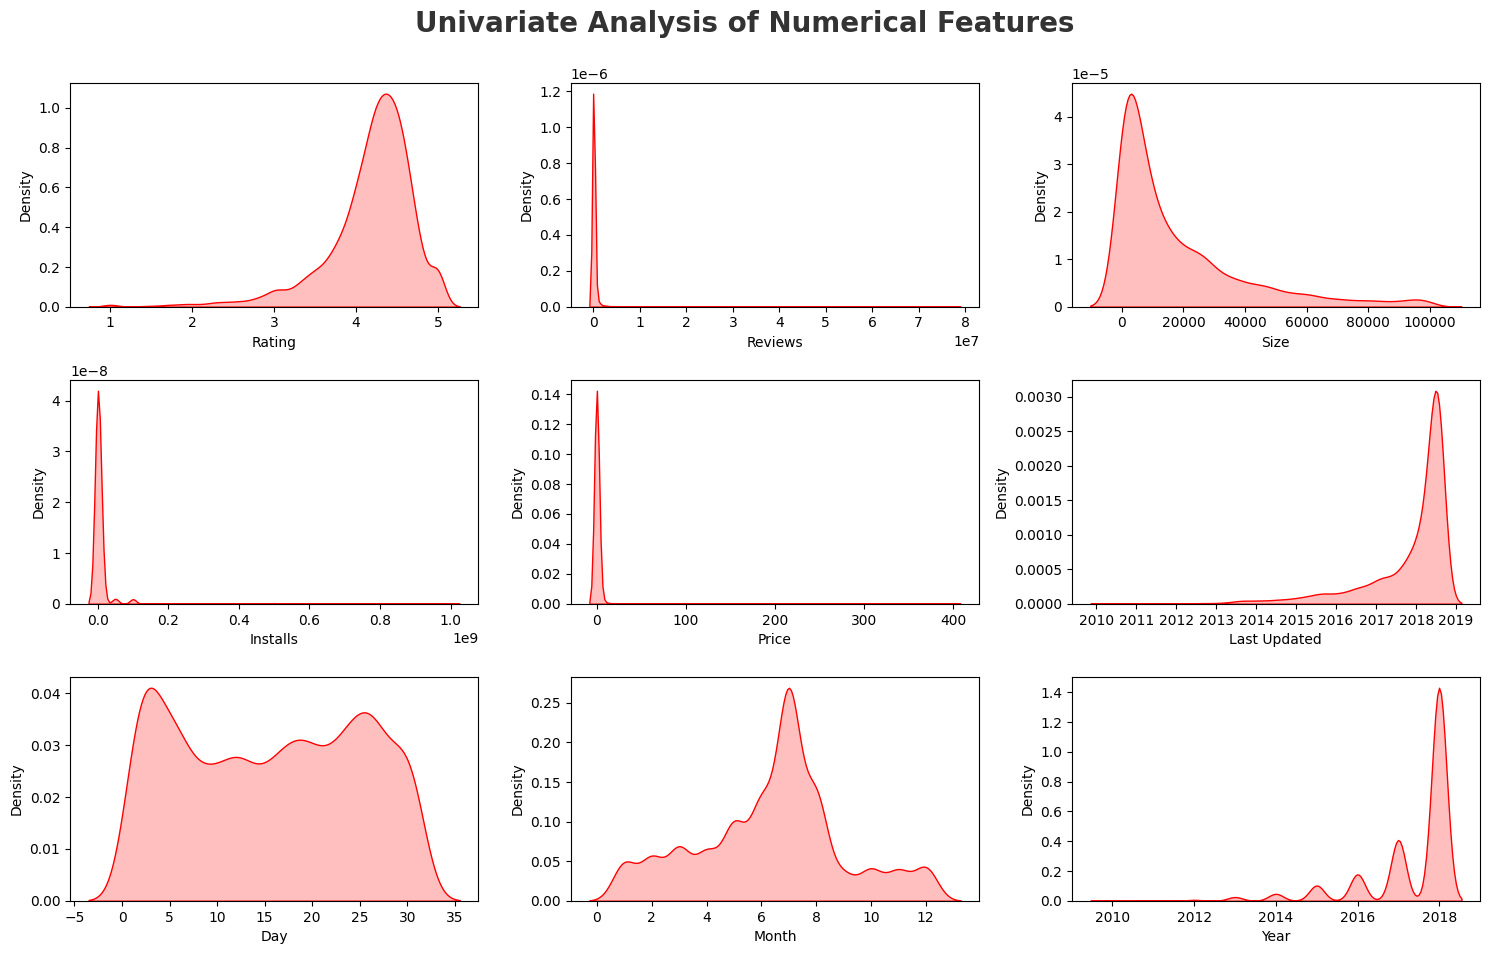

In [243]:
## Proportion of count data on numerical columns
plt.figure(figsize=(15, 15))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)

for i in range(0, len(numeric_features)):
    plt.subplot(5, 3, i+1)
    sns.kdeplot(x=df_copy[numeric_features[i]],shade=True, color='r')
    plt.xlabel(numeric_features[i])
    plt.tight_layout()

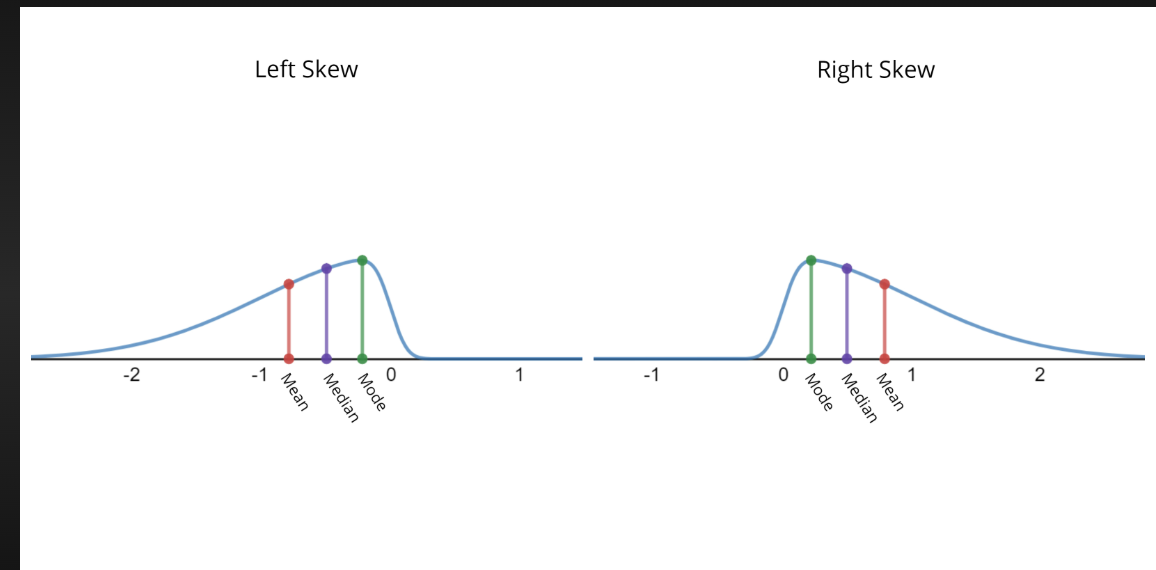

### Observations-:
Rating and Year is left skewed while Reviews, Size,Installs and Price are rigth Skewed

In [244]:
# This code creates KDE (density) plots for all numerical columns to visualize their distributions.

# What each part does:
# plt.figure(figsize=(15, 15)) → creates a big figure
# plt.suptitle(...) → adds a main title for all plots
# for i in range(...): → loops through each numeric feature
# plt.subplot(5, 3, i+1) → arranges plots in a 5×3 grid
# sns.kdeplot(...) → draws a density (KDE) plot for that column
# plt.xlabel(...) → labels each plot
# plt.tight_layout() → adjusts spacing

# In simple words:
# It plots smooth distribution curves for every numerical feature to analyze their spread and patterns (univariate analysis).

In [245]:
# KDE needs continuous numeric values to estimate a smooth distribution curve.
# Categorical data has labels, not continuous numbers.

# Use instead:
# For categorical data, use:

# Bar plot
# Count plot
# Pie chart
# One-line:

# KDE = numeric continuous data only ❌ categorical data.

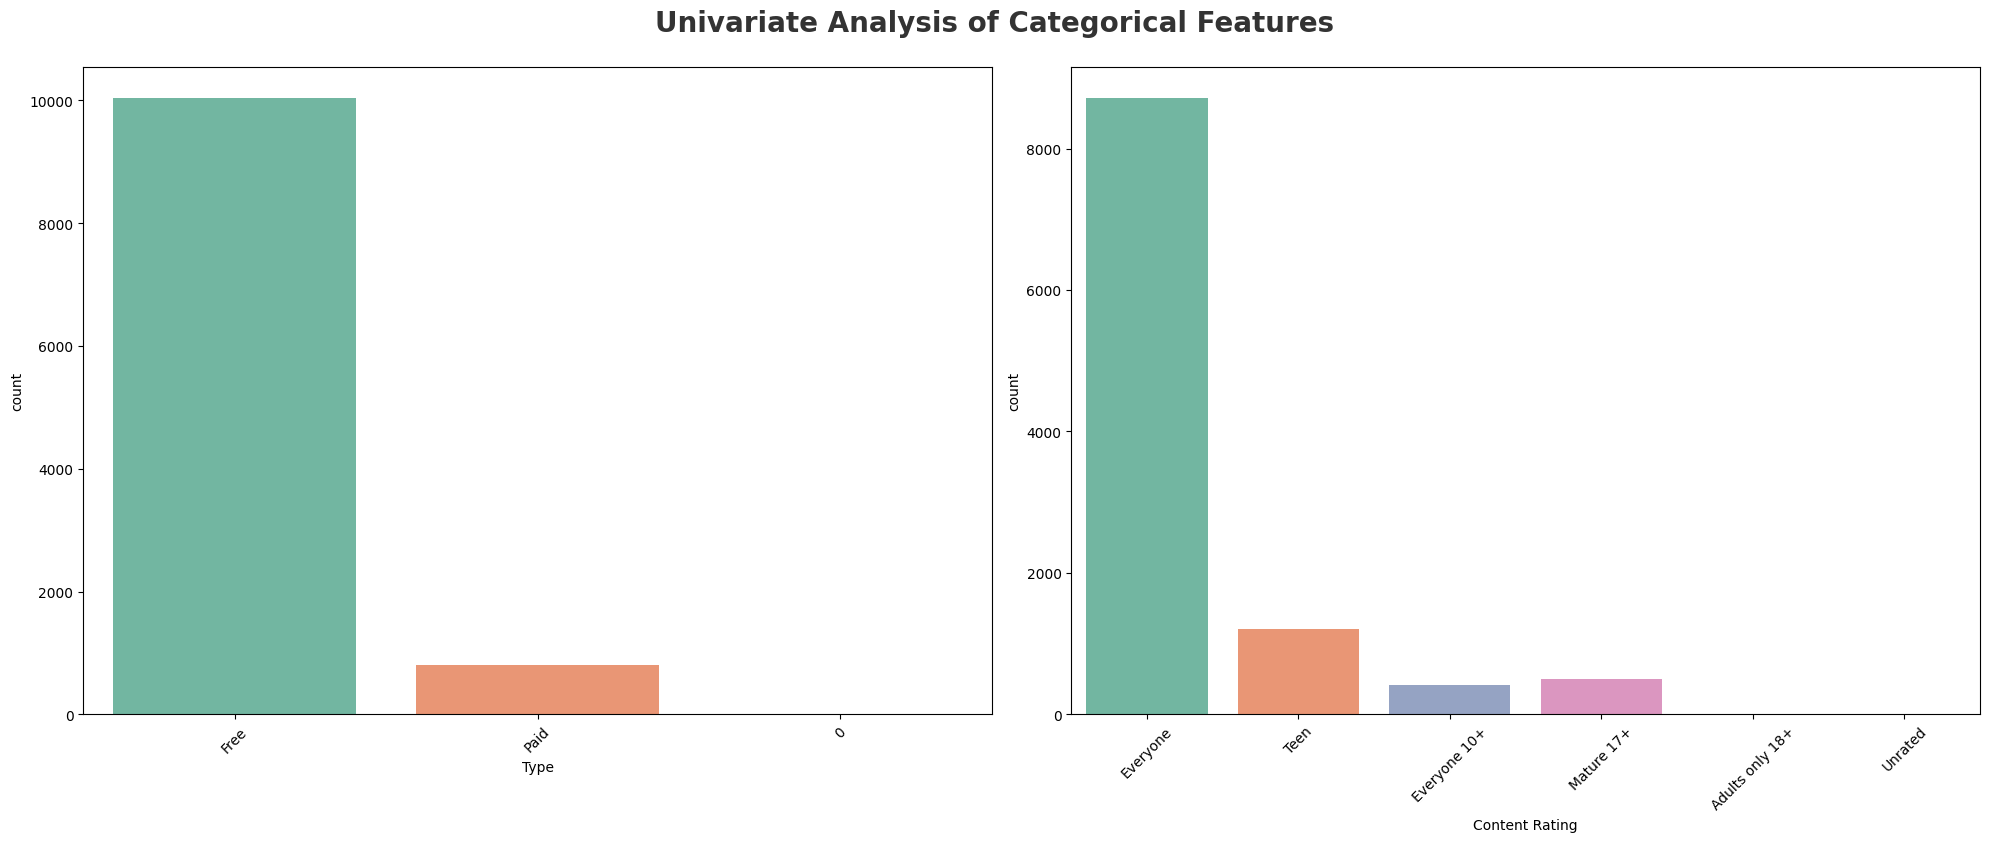

In [246]:
# categorical columns
plt.figure(figsize=(20, 15))
plt.suptitle('Univariate Analysis of Categorical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.)
category = [ 'Type', 'Content Rating']
for i in range(0, len(category)):
    plt.subplot(2, 2, i+1)
    sns.countplot(x=df[category[i]],palette="Set2")
    plt.xlabel(category[i])
    plt.xticks(rotation=45)
    plt.tight_layout() 

In [247]:
# For category columns -: countplot() => Univariate Analysis
# For numerical columns -: kdeplot() => Univariate Analysis

### Which is the most popular app category??

In [248]:
df_copy.head(2)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Day,Month,Year
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19000,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,7,1,2018
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14000,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,15,1,2018


In [249]:
df_copy["Category"].value_counts()

Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           163
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
ART_AND_DESIGN           64
EVENTS                   64
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64

In [250]:
# plot.pie() is a pandas plotting function, powered by matplotlib under the hood.

<Axes: ylabel='count'>

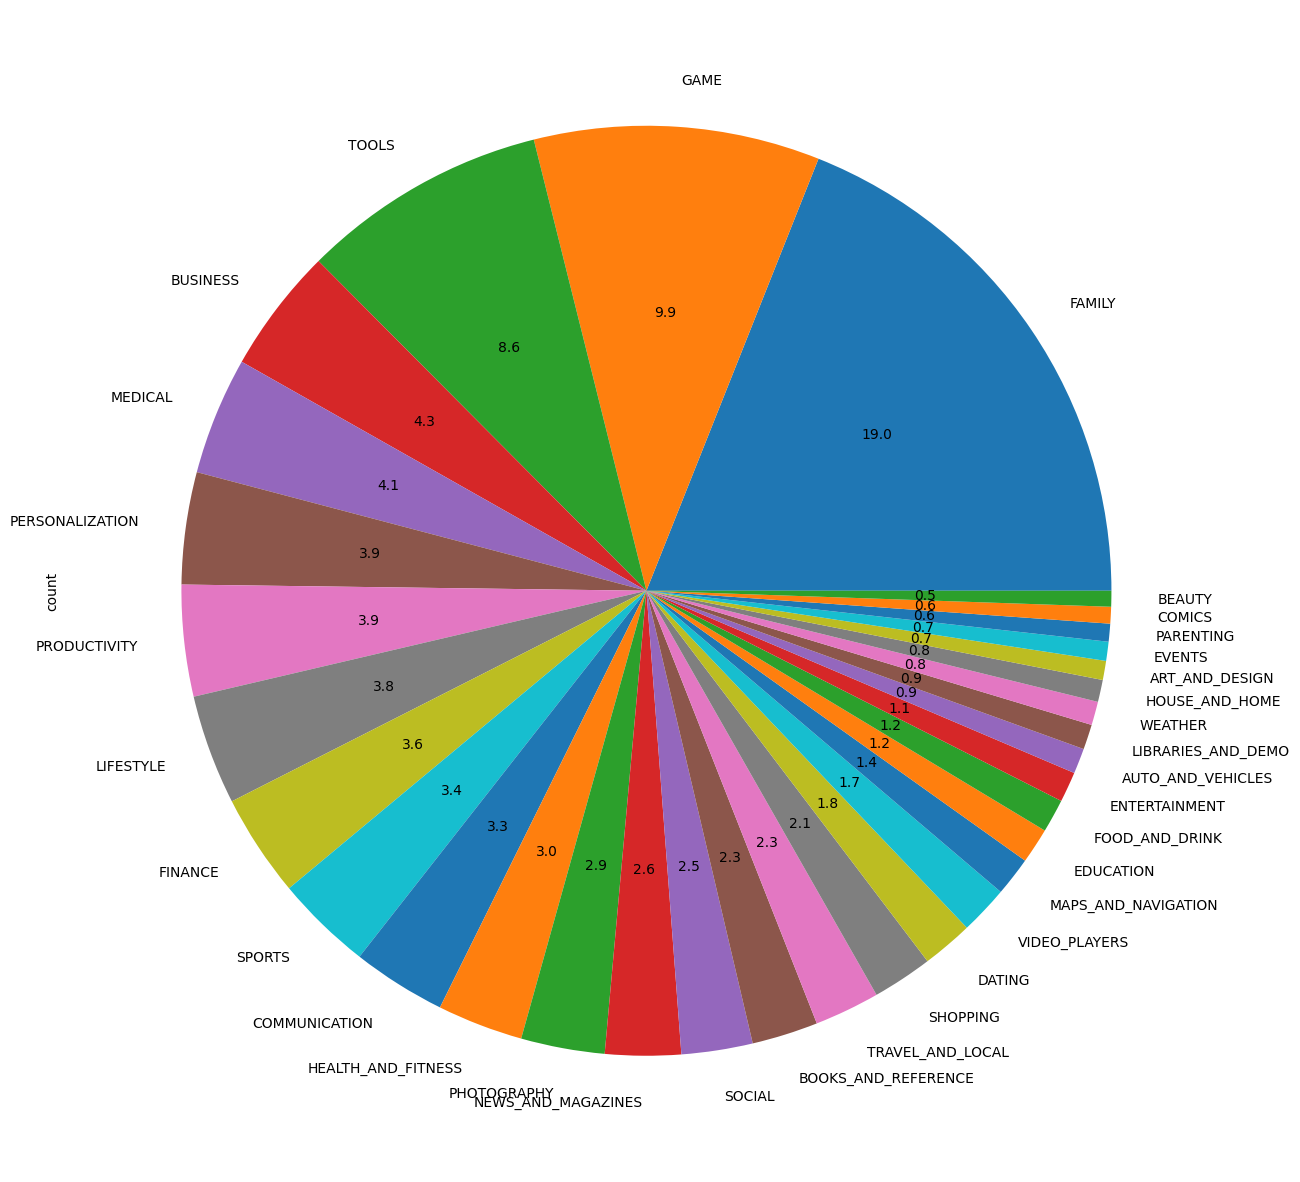

In [251]:
# y means:
# the data values to be plotted on the pie chart.
df_copy['Category'].value_counts().plot.pie(y=df_copy['Category'],figsize=(15,16),autopct='%1.1f')

In [252]:
# **`autopct` = automatic percentage formatting** for pie charts 🍰
# ### Meaning:

# ```python
# autopct='%1.1f'
# ```

# ➡ It displays the **percentage value on each pie slice**.
# ### Format:

# * `%1.1f` → 1 decimal place
# * `%1.0f` → no decimal
# * `%1.2f` → 2 decimals

# ### Example:
# If a slice = 25%
# It will show → `25.0%`

# ### One-line:
# > `autopct` automatically prints percentage labels on pie chart slices.

## Observations

1. There are more kinds of apps in playstore which are under category of family, games & tools
2. Beatuty,comics,arts and weather kinds of apps are very less in playstore

In [253]:
# Top 10 App Categories-:
category = pd.DataFrame(df_copy['Category'].value_counts())        #Dataframe of apps on the basis of category
category.rename(columns = {'Category':'Count'},inplace=True)

In [254]:
category

,count
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345
